renewal_model_dataset
        ↓
X and y
        ↓
Train / Test Split
        ↓
Preprocessing Pipeline
   ├── Numeric Imputation
   └── One-Hot Encoding
        ↓
Dummy Baseline
        ↓
Logistic Regression
        ↓
Random Forest
        ↓
XGBoost
        ↓
Confusion Matrix
        ↓
Precision / Recall / F1
        ↓
ROC-AUC + PR-AUC
        ↓
Threshold Tuning
        ↓
Feature Importance
        ↓
Choose Model
        ↓
Save Model

Our target is:
NON_RENEWAL_FLAG

1 = Lapsed / Cancelled   ← positive class
0 = Renewed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import joblib

pd.set_option("display.max_columns", None)

print('imported succesfully')

In [2]:
PROJECT_DIR = Path.cwd().parent

MODEL_DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "curated"
)

model_df = pd.read_csv(
    MODEL_DATA_DIR
    / "renewal_model_dataset.csv",
    low_memory=False
)

print(model_df.shape)

(19204, 60)


In [3]:
print("Duplicate Policy IDs:", model_df["POLICY_ID"].duplicated().sum())

print(model_df["NON_RENEWAL_FLAG"].value_counts())

Duplicate Policy IDs: 0
NON_RENEWAL_FLAG
0    17334
1     1870
Name: count, dtype: int64


In [4]:
model_df["NON_RENEWAL_FLAG"].value_counts(normalize=True).mul(100).round(2)

NON_RENEWAL_FLAG
0    90.26
1     9.74
Name: proportion, dtype: float64

In [5]:
numeric_features = [
    "AGE",
    "ANNUAL_INCOME",
    "CREDIT_SCORE",

    "SUM_INSURED",
    "ANNUAL_PREMIUM",
    "RISK_SCORE",
    "DISCOUNT_PCT",
    "COMMISSION_PCT",
    "POLICY_TERM_DAYS",
    "PREMIUM_TO_SUM_INSURED_PCT",

    "HEALTH_SCORE",
    "BMI",
    "UNDERWRITING_SCORE",
    "PREMIUM_LOADING_PCT",

    "OLD_PREMIUM",
    "NEW_PREMIUM",
    "PREMIUM_INCREASE_PCT",
    "PREMIUM_CHANGE_AMOUNT",
    "NEW_PREMIUM_TO_INCOME_PCT",
    "LOYALTY_YEARS",

    "TOTAL_DUE_TXNS_PRIOR",
    "PAID_TXNS_PRIOR",
    "UNPAID_TXNS_AT_RENEWAL",
    "TOTAL_PREMIUM_DUE_PRIOR",
    "TOTAL_PREMIUM_PAID_PRIOR",
    "AVG_PAYMENT_DELAY_PRIOR",
    "MAX_PAYMENT_DELAY_PRIOR",
    "PAYMENT_SUCCESS_RATE_PRIOR",

    "TOTAL_CLAIMS_PRIOR",
    "TOTAL_CLAIM_AMOUNT_PRIOR",
    "AVG_CLAIM_AMOUNT_PRIOR",
    "MAX_CLAIM_AMOUNT_PRIOR",
    "DAYS_SINCE_LAST_CLAIM",

    "HAS_PAYMENT_HISTORY_PRIOR",
    "HAS_CLAIM_HISTORY_PRIOR",
    "HAS_UNPAID_PAYMENT_AT_RENEWAL",
    "HAS_UNDERWRITING_RECORD",
    "PREMIUM_INCREASED_FLAG",
    "HIGH_PREMIUM_INCREASE_FLAG"
]

categorical_features = [
    "GENDER",
    "MARITAL_STATUS",
    "OCCUPATION",
    "STATE",
    "CUSTOMER_RISK_SEGMENT",

    "POLICY_TYPE",
    "SALES_CHANNEL",
    "PAYMENT_MODE",
    "RISK_BAND",

    "LIFESTYLE",
    "MEDICAL_HISTORY_FLAG",
    "SMOKER_FLAG",
    "OCCUPATION_RISK",
    "UW_DECISION",

    "CONTACT_CHANNEL"
]

In [6]:
all_features = (numeric_features + categorical_features)

In [7]:
missing_features = [col for col in all_features if col not in model_df.columns]

print("Missing Features:", missing_features)

Missing Features: []


In [8]:
X = model_df[all_features].copy()
y = model_df["NON_RENEWAL_FLAG"].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (19204, 54)
y: (19204,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [10]:
print("Train non-renewal %:", round(y_train.mean() * 100, 2))
print("Test non-renewal %:", round(y_test.mean() * 100, 2))

Train non-renewal %: 9.74
Test non-renewal %: 9.74


In [ ]:
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

In [12]:
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

In [13]:
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features)])

First Model — Dummy Baseline

In [14]:
dummy_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", DummyClassifier(strategy="most_frequent"))])

In [15]:
dummy_pipeline.fit( X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['AGE','ANNUAL_INCOME','CREDIT_SCORE',...,'OCCUPATION_RISK','UW_DECISION', 'CONTACT_CHANNEL']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [16]:
dummy_pred = dummy_pipeline.predict(
    X_test
)

In [17]:
print(classification_report(y_test, dummy_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3467
           1       0.00      0.00      0.00       374

    accuracy                           0.90      3841
   macro avg       0.45      0.50      0.47      3841
weighted avg       0.81      0.90      0.86      3841



Build Reusable Evaluation Function  

In [19]:
def evaluate_model(name, model, X_test, y_test, threshold=0.50):

    probabilities = model.predict_proba(X_test)[:, 1]

    predictions = (probabilities >= threshold).astype(int)

    print("\n", "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy :", round(accuracy_score(y_test, predictions), 4))
    print("Precision:", round(precision_score(y_test, predictions, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_test, predictions, zero_division=0), 4))
    print("F1       :", round(f1_score(y_test, predictions, zero_division=0), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_test, probabilities), 4))
    print("PR-AUC   :", round(average_precision_score(y_test, probabilities), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))

                 Predicted

               Renew   Non-Renew

Actual Renew      TN       FP

Actual NonRenew   FN       TP

TP — True Positive
Customer would not renew and model identified them.
✅ Good retention lead.
FN — False Negative
Customer would not renew but model missed them.
❌ Important business loss.
FP — False Positive
Model flagged customer as at risk but customer would have renewed anyway.
This costs:

Why Recall Matters


In [ ]:
TP
--------
TP + FN

Of all customers who actually did not renew, how many did we identify?

If retention is the business objective, this is important.

In [ ]:
Why Precision Matters

TP
--------
TP + FP

In [23]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

In [25]:
evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    X_test,
    y_test
)


Logistic Regression
Accuracy : 0.5923
Precision: 0.1247
Recall   : 0.5294
F1       : 0.2018
ROC-AUC  : 0.5942
PR-AUC   : 0.1372

Confusion Matrix:
[[2077 1390]
 [ 176  198]]


In [24]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['AGE','ANNUAL_INCOME','CREDIT_SCORE',...,'OCCUPATION_RISK','UW_DECISION', 'CONTACT_CHANNEL']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [20]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [21]:
rf_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['AGE','ANNUAL_INCOME','CREDIT_SCORE',...,'OCCUPATION_RISK','UW_DECISION', 'CONTACT_CHANNEL']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [22]:
evaluate_model("Random Forest",rf_pipeline,X_test,y_test)


Random Forest
Accuracy : 0.8805
Precision: 0.2293
Recall   : 0.0963
F1       : 0.1356
ROC-AUC  : 0.5805
PR-AUC   : 0.1501

Confusion Matrix:
[[3346  121]
 [ 338   36]]


In [26]:
# XGBoost — Calculate Class Weight

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 9.27


In [27]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [29]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['AGE','ANNUAL_INCOME','CREDIT_SCORE',...,'OCCUPATION_RISK','UW_DECISION', 'CONTACT_CHANNEL']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [30]:
evaluate_model(
    "XGBoost",
    xgb_pipeline,
    X_test,
    y_test
)


XGBoost
Accuracy : 0.7303
Precision: 0.1363
Recall   : 0.3316
F1       : 0.1931
ROC-AUC  : 0.5724
PR-AUC   : 0.1336

Confusion Matrix:
[[2681  786]
 [ 250  124]]


In [31]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

In [32]:
model_results = []

for name, model in models.items():

    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    model_results.append({
        "MODEL": name,
        "ACCURACY": accuracy_score(y_test, predictions),
        "PRECISION": precision_score(y_test, predictions, zero_division=0),
        "RECALL": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, probabilities),
        "PR_AUC": average_precision_score(y_test, probabilities)
    })

In [33]:
model_results_df = pd.DataFrame(model_results)

model_results_df.sort_values("PR_AUC", ascending=False)

,MODEL,ACCURACY,PRECISION,RECALL,F1,ROC_AUC,PR_AUC
1,Random Forest,0.880500,0.229299,0.096257,0.135593,0.580501,0.150094
0,Logistic Regression,0.592294,0.124685,0.529412,0.201835,0.594204,0.137213
2,XGBoost,0.730279,0.136264,0.331551,0.193146,0.572385,0.133637


If our retention goal is catching at-risk policies:
Random Forest's:
91% Accuracy

does not automatically make it best.
It only captures:
20% of actual non-renewers.

That's poor retention coverage.

In [34]:
# Use the Best Candidate's Probabilities
best_model = xgb_pipeline

test_probabilities = best_model.predict_proba(X_test)[:, 1]

In [36]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60]

threshold_results = []

for threshold in thresholds:

    pred = (test_probabilities >= threshold).astype(int)

    threshold_results.append({
        "THRESHOLD": threshold,
        "PRECISION": precision_score(y_test, pred, zero_division=0),
        "RECALL": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "CUSTOMERS_FLAGGED": pred.sum()
    })

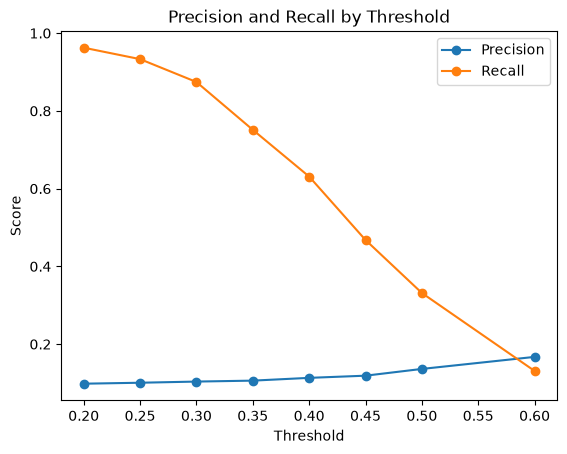

In [38]:
plt.plot(threshold_df["THRESHOLD"], threshold_df["PRECISION"], marker="o", label="Precision")
plt.plot(threshold_df["THRESHOLD"], threshold_df["RECALL"], marker="o", label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall by Threshold")
plt.legend()
plt.show()

In [39]:
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [40]:
xgb_model = xgb_pipeline.named_steps["model"]

In [41]:
feature_importance = pd.DataFrame({
    "FEATURE": feature_names,
    "IMPORTANCE": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "IMPORTANCE",
    ascending=False
)

feature_importance.head(20)

,FEATURE,IMPORTANCE
38,num__HIGH_PREMIUM_INCREASE_FLAG,0.051688
72,cat__POLICY_TYPE_Travel,0.018386
16,num__PREMIUM_INCREASE_PCT,0.015935
104,cat__CONTACT_CHANNEL_SMS,0.015255
86,cat__RISK_BAND_Medium,0.014430
88,cat__LIFESTYLE_Excellent,0.013236
101,cat__CONTACT_CHANNEL_Agent Visit,0.012378
19,num__LOYALTY_YEARS,0.011859
73,cat__POLICY_TYPE_Whole Life,0.011828
69,cat__POLICY_TYPE_Motor,0.011788


In [42]:
feature_importance["FEATURE"] = (
    feature_importance["FEATURE"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

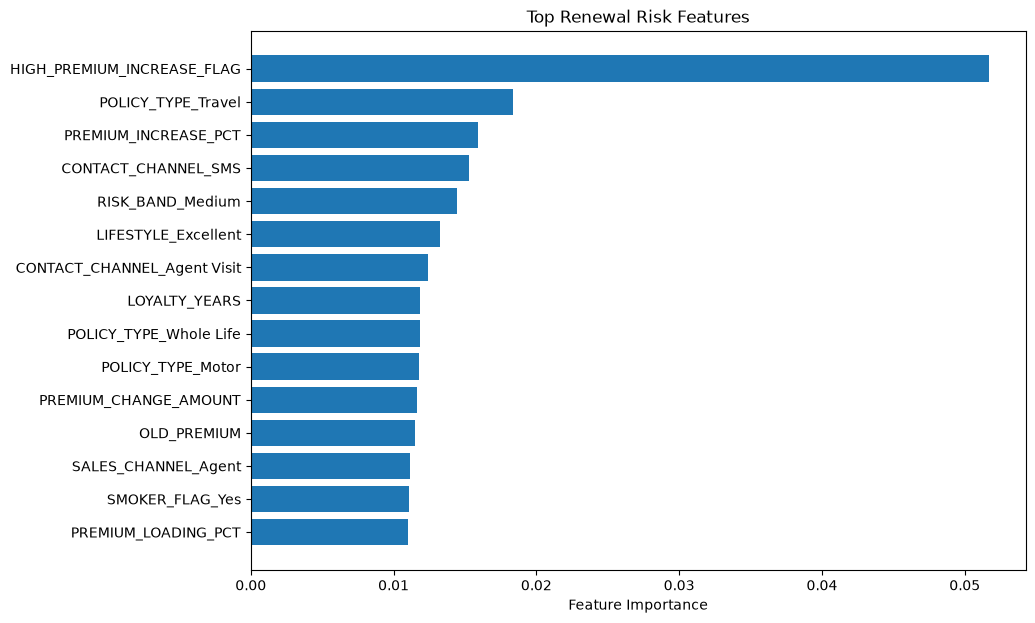

In [43]:
top_features = feature_importance.head(15).sort_values("IMPORTANCE")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["FEATURE"],
    top_features["IMPORTANCE"]
)

plt.title("Top Renewal Risk Features")
plt.xlabel("Feature Importance")

plt.show()

In [44]:
MODELS_DIR = (
    PROJECT_DIR
    / "models"
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [45]:
best_model = xgb_pipeline

In [46]:
joblib.dump(
    best_model,
    MODELS_DIR
    / "renewal_xgboost_model.joblib"
)

['f:\\insurance_ai_copilot\\models\\renewal_xgboost_model.joblib']

In [47]:
selected_threshold = 0.35

In [48]:
joblib.dump(
    selected_threshold,
    MODELS_DIR
    / "renewal_churn_threshold.joblib"
)

['f:\\insurance_ai_copilot\\models\\renewal_churn_threshold.joblib']

In [49]:
loaded_model = joblib.load(
    MODELS_DIR
    / "renewal_xgboost_model.joblib"
)

loaded_threshold = joblib.load(
    MODELS_DIR
    / "renewal_churn_threshold.joblib"
)

In [50]:
sample = X_test.iloc[
    [0]
]

In [51]:
probability = (
    loaded_model
    .predict_proba(sample)[0, 1]
)

print(
    "Non-Renewal Probability:",
    round(probability, 4)
)

Non-Renewal Probability: 0.4515


In [52]:
prediction = int(
    probability
    >= loaded_threshold
)

print(
    "High Risk:",
    prediction
)

High Risk: 1


Business:
Reduce avoidable non-renewal
        ↓

Prediction Point:
Before final renewal decision
        ↓

Target:
NON_RENEWAL_FLAG
        ↓

Positive Class:
Lapsed / Cancelled
        ↓

Leakage Prevention:
No renewal status/probability/future events
        ↓

Time-Aware:
Payments + Claims prior to renewal
        ↓

Imbalanced Target:
~9.7% positive
        ↓

Baseline:
Dummy Model
        ↓

Models:
Logistic
Random Forest
XGBoost
        ↓

Metrics:
Precision
Recall
F1
ROC-AUC
PR-AUC
        ↓

Threshold:
Chosen around retention capacity/business cost